<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 145 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Structural Equation Modeling & Mixed Models</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Students are nested in schools, so their rows are not independent. We fit a random-intercept mixed model with statsmodels, read the ICC and the study effect, see partial-pooling shrinkage, then build a small measurement model that pulls one latent factor from six survey items.</div>
</div>

Run top to bottom. Uses **pandas**, **statsmodels** (`mixedlm`), and **scikit-learn** (`FactorAnalysis`). The data is simulated with a known structure so the model has a truth to recover.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, VI, GR = "#a21caf", "#7c3aed", "#16a34a"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "structural-equation-modeling-and-mixed-models--student-scores.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape); print(df.head())

(1016, 3)
   school  hours_studied  test_score
0  SCH100            4.6        57.6
1  SCH100            6.3        74.5
2  SCH100            4.2        73.7
3  SCH100            5.9        65.1
4  SCH100            2.7        73.2


## DEMO 1 &middot; Explore first: do schools differ?
Before modeling, check whether the grouping matters. If school mean scores vary a lot, the students are clearly not independent and ordinary regression is the wrong tool.

40 schools, 1016 students
school mean score ranges 54.6 to 78.7  (grand mean 67.4)


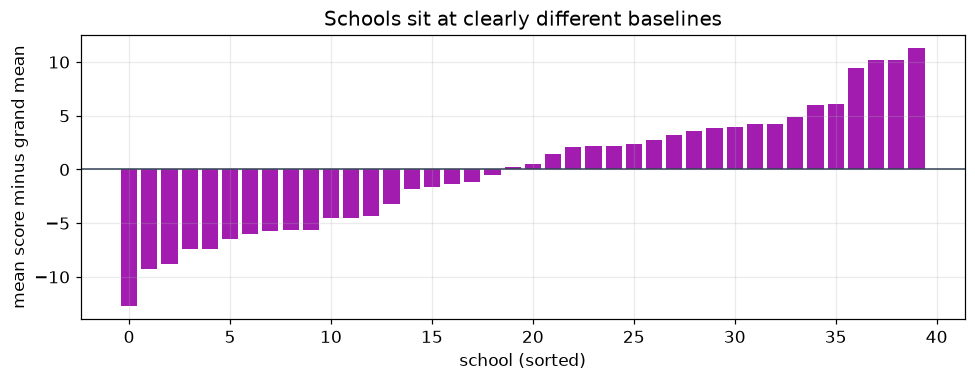

In [2]:
sm = df.groupby("school")["test_score"].agg(["size", "mean"]).sort_values("mean")
print(f"{df.school.nunique()} schools, {len(df)} students")
print(f"school mean score ranges {sm['mean'].min():.1f} to {sm['mean'].max():.1f}  (grand mean {df.test_score.mean():.1f})")
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(range(len(sm)), sm["mean"] - df.test_score.mean(), color=FU)
ax.axhline(0, color="#334155", lw=1)
ax.set_xlabel("school (sorted)"); ax.set_ylabel("mean score minus grand mean"); ax.set_title("Schools sit at clearly different baselines")
plt.tight_layout(); plt.show()

## DEMO 2 &middot; Pooled OLS vs a random-intercept mixed model
OLS treats all 1,016 students as independent. The mixed model adds a random intercept per school and reports how much variance is *between* schools, the ICC.

In [3]:
ols = smf.ols("test_score ~ hours_studied", data=df).fit()
mi  = smf.mixedlm("test_score ~ hours_studied", df, groups=df["school"]).fit()
gv, rv = float(mi.cov_re.iloc[0, 0]), float(mi.scale)
icc = gv / (gv + rv)
print(f"OLS   hours slope = {ols.params['hours_studied']:.3f}  (SE {ols.bse['hours_studied']:.3f})")
print(f"Mixed hours slope = {mi.fe_params['hours_studied']:.3f}  (SE {mi.bse['hours_studied']:.3f})")
print(f"between-school variance = {gv:.1f} (sd {gv**0.5:.1f})")
print(f"within-student variance = {rv:.1f} (sd {rv**0.5:.1f})")
print(f"ICC = {icc:.3f}  ->  {icc:.0%} of the leftover variance is BETWEEN schools")

OLS   hours slope = 2.369  (SE 0.151)
Mixed hours slope = 2.310  (SE 0.129)
between-school variance = 29.0 (sd 5.4)
within-student variance = 66.9 (sd 8.2)
ICC = 0.303  ->  30% of the leftover variance is BETWEEN schools


## DEMO 3 &middot; Partial pooling and shrinkage
The mixed model does not trust each school's raw mean fully; it shrinks extreme or small schools toward the overall average, borrowing strength. Plot the raw school deviation against the model's shrunk estimate.

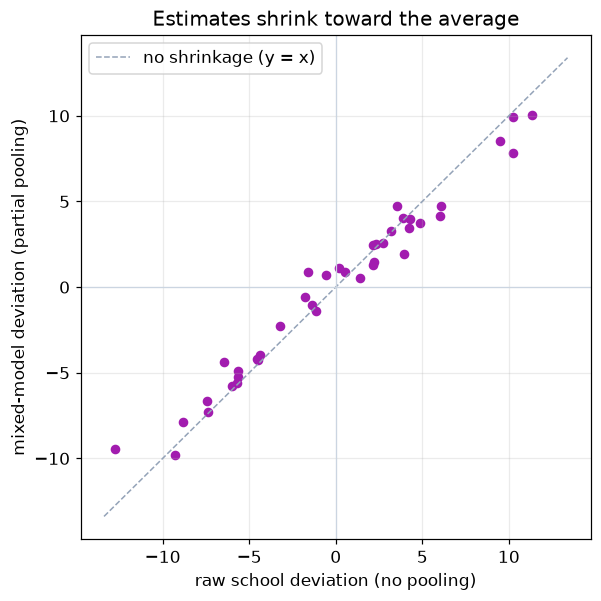

mean |raw dev| = 4.83  ->  mean |shrunk dev| = 4.24 (pulled in)


In [4]:
grand = df.test_score.mean()
raw_dev = (df.groupby("school")["test_score"].mean() - grand)
re = mi.random_effects
shrunk = pd.Series({g: float(re[g].iloc[0]) for g in raw_dev.index})
fig, ax = plt.subplots(figsize=(5.6, 5.6))
lim = 1.05 * max(raw_dev.abs().max(), shrunk.abs().max())
ax.plot([-lim, lim], [-lim, lim], color="#94a3b8", ls="--", lw=1, label="no shrinkage (y = x)")
ax.axhline(0, color="#cbd5e1", lw=0.8); ax.axvline(0, color="#cbd5e1", lw=0.8)
ax.scatter(raw_dev, shrunk, color=FU, s=28)
ax.set_xlabel("raw school deviation (no pooling)"); ax.set_ylabel("mixed-model deviation (partial pooling)")
ax.set_title("Estimates shrink toward the average"); ax.legend()
plt.tight_layout(); plt.show()
print("mean |raw dev| =", round(raw_dev.abs().mean(), 2), " ->  mean |shrunk dev| =", round(shrunk.abs().mean(), 2), "(pulled in)")

## DEMO 4 &middot; Does the effect itself vary? (random slope)
A random slope lets the hours-to-score relationship differ by school. Here the slope variance is tiny, a useful negative result: studying pays off about equally everywhere; only the baseline differs.

In [5]:
ms = smf.mixedlm("test_score ~ hours_studied", df, groups=df["school"], re_formula="~hours_studied").fit()
print(f"average (fixed) hours slope = {ms.fe_params['hours_studied']:.3f}")
print(f"intercept variance across schools = {ms.cov_re.iloc[0,0]:.1f}")
print(f"slope    variance across schools = {ms.cov_re.iloc[1,1]:.3f}  (near zero -> slope barely varies)")

average (fixed) hours slope = 2.307
intercept variance across schools = 24.6
slope    variance across schools = 0.008  (near zero -> slope barely varies)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## DEMO 5 &middot; A latent variable (the SEM measurement model)
Now the other half of the chapter. Six survey items are noisy echoes of one hidden trait, 'motivation'. A measurement model extracts that latent factor and reports how strongly each item loads on it.

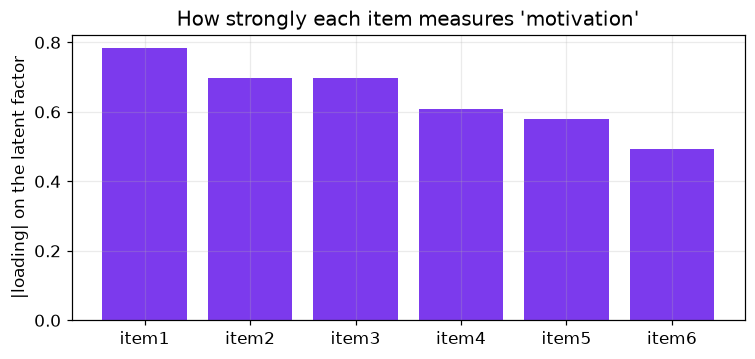

estimated loadings: [0.78 0.7  0.7  0.61 0.58 0.49]
structural path (latent motivation -> outcome) = 6.01 points per SD of the factor


In [6]:
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(7); N = 600
motivation = rng.normal(0, 1, N)                              # the true latent trait (unobserved in practice)
loads_true = [0.8, 0.75, 0.7, 0.65, 0.6, 0.55]
items = pd.DataFrame({f"item{k+1}": L*motivation + np.sqrt(1-L**2)*rng.normal(0, 1, N)
                      for k, L in enumerate(loads_true)})
Z = StandardScaler().fit_transform(items)
fa = FactorAnalysis(n_components=1, random_state=0).fit(Z)
loadings = fa.components_[0]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(items.columns, np.abs(loadings), color=VI)
ax.set_ylabel("|loading| on the latent factor"); ax.set_title("How strongly each item measures 'motivation'")
plt.tight_layout(); plt.show()
print("estimated loadings:", np.round(loadings, 2))
# use the factor score in a structural path: motivation -> an outcome
score = fa.transform(Z)[:, 0]
outcome = 50 + 6*score + rng.normal(0, 5, N)
path = np.polyfit(score, outcome, 1)[0]
print(f"structural path (latent motivation -> outcome) = {path:.2f} points per SD of the factor")

### Wrap-up
Two extensions of the linear model, one lesson: model the structure you actually have. The mixed model showed **30%** of score variance lives between schools (ICC 0.30) and recovered the **2.31**-point hours effect while shrinking small schools toward the average. The measurement model pulled a single latent 'motivation' factor out of six noisy items and carried it into a structural path. Next in Part XXIV: the **Deep Learning Primer**, where latent factors become learned representations.